In [27]:
# AI-Driven Impulsive Spending Detection & Risk Prediction System

# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

# Ignore warnings for clean output
warnings.filterwarnings('ignore')

# Use a clean plotting style
plt.style.use('ggplot')

In [30]:
# 1. LOAD AND PREPARE DATA

df = pd.read_csv(r"C:\Users\DELL\Downloads\financial_impulse_clean_dataset.csv")

# Convert Timestamp column into datetime format
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract time-based features for behavioural analysis
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek

In [31]:
# 2. FEATURE ENGINEERING (Trigger Detection)

# Timing-Based Triggers

# Late-night spending trigger (10 PM to 4 AM)
df['Is_Late_Night'] = df['Hour'].apply(
    lambda x: 1 if (x >= 22 or x <= 4) else 0
)

# End-of-month spending trigger (25th onwards)
df['Is_End_of_Month'] = df['Day'].apply(
    lambda x: 1 if x >= 25 else 0
)

# Weekend spending trigger (Saturday & Sunday)
df['Is_Weekend'] = df['Day_of_Week'].apply(
    lambda x: 1 if x >= 5 else 0
)

In [32]:
# Merchant Category Impulse Detection

# Define impulse-driven categories
impulse_cats = ['Entertainment', 'Food Delivery', 'Shopping', 'Travel']

# Mark transactions as impulse (1) or non-impulse (0)
df['Is_Impulse'] = df['Merchant_Category'].apply(
    lambda x: 1 if x in impulse_cats else 0
)

# Calculate impulse spending amount
df['Impulse_Amount'] = df['Amount'] * df['Is_Impulse']

In [33]:
# Spending Frequency Volatility

# Calculate daily transaction count per user
daily_counts = df.groupby(['User_ID', df['Timestamp'].dt.date]).size() \
                 .reset_index(name='Daily_Tx_Count')

# Calculate standard deviation of daily transactions (volatility)
user_volatility = daily_counts.groupby('User_ID')['Daily_Tx_Count'] \
                               .std() \
                               .fillna(0) \
                               .reset_index(name='Freq_Volatility')

In [34]:
# 3. PREDICTIVE MODELING (Machine Learning)

# Goal:
# Train model on Months 1-5
# Predict high impulse risk in Month 6

# Define Month 6 target variable:
# High risk if average impulse ratio > 40%
m6_target = (
    df[df['Month'] == 6]
    .groupby('User_ID')['Is_Impulse']
    .mean() > 0.4
).astype(int)

# Create training features from Months 1-5
train_features = df[df['Month'] < 6].groupby('User_ID').agg({
    'Amount': 'mean',
    'Is_Impulse': 'mean',
    'Is_Late_Night': 'mean',
    'Is_End_of_Month': 'mean'
}).rename(columns={
    'Amount': 'Avg_Spend',
    'Is_Impulse': 'Impulse_Ratio',
    'Is_Late_Night': 'Late_Night_Ratio',
    'Is_End_of_Month': 'EOM_Ratio'
})

# Keep only common users for training
common_users = train_features.index.intersection(m6_target.index)

# Initialize Random Forest classifier
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
clf.fit(
    train_features.loc[common_users],
    m6_target.loc[common_users]
)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
# 4. USER-LEVEL AGGREGATION & RISK SCORING

# Aggregate user-level behavioural metrics
user_metrics = df.groupby('User_ID').agg({
    'Amount': ['mean', 'sum'],
    'Is_Impulse': 'mean',
    'Is_Late_Night': 'mean',
    'Is_End_of_Month': 'mean',
    'Income': 'first'
})

# Rename columns properly
user_metrics.columns = [
    'Avg_Spend',
    'Total_Spend',
    'Impulse_Ratio',
    'Late_Night_Ratio',
    'EOM_Ratio',
    'Income'
]

# Reset index
user_metrics = user_metrics.reset_index()

# Merge volatility feature
user_metrics = user_metrics.merge(user_volatility, on='User_ID')

In [36]:
# 4. USER-LEVEL AGGREGATION & RISK SCORING

# Aggregate user-level behavioural metrics
user_metrics = df.groupby('User_ID').agg({
    'Amount': ['mean', 'sum'],
    'Is_Impulse': 'mean',
    'Is_Late_Night': 'mean',
    'Is_End_of_Month': 'mean',
    'Income': 'first'
})

# Rename columns properly
user_metrics.columns = [
    'Avg_Spend',
    'Total_Spend',
    'Impulse_Ratio',
    'Late_Night_Ratio',
    'EOM_Ratio',
    'Income'
]

# Reset index
user_metrics = user_metrics.reset_index()

# Merge volatility feature
user_metrics = user_metrics.merge(user_volatility, on='User_ID')

In [37]:
# Predict Risk Probability

# Prepare input features for ML prediction
X_all = user_metrics[['Avg_Spend', 
                      'Impulse_Ratio', 
                      'Late_Night_Ratio', 
                      'EOM_Ratio']]

# Get probability of high-risk class
user_metrics['Predicted_Risk_Prob'] = clf.predict_proba(X_all)[:, 1]

In [38]:
# Final Composite Risk Score (0-100)

# Weighted formula:
# 30% Impulse Ratio
# 20% Late Night Ratio
# 10% Frequency Volatility
# 40% ML Prediction Probability

user_metrics['Impulse_Risk_Score'] = (
    (user_metrics['Impulse_Ratio'] * 30) +
    (user_metrics['Late_Night_Ratio'] * 20) +
    (user_metrics['Freq_Volatility'] * 10) +
    (user_metrics['Predicted_Risk_Prob'] * 40)
).clip(0, 100).round(2)

In [39]:
# 5. BEHAVIOURAL CLUSTERING (User Profiling)

# Standardize data before clustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(
    user_metrics[['Impulse_Ratio',
                  'Late_Night_Ratio',
                  'Avg_Spend']]
)

# Apply K-Means clustering (4 behavioural groups)
kmeans = KMeans(n_clusters=4, random_state=42)
user_metrics['Cluster'] = kmeans.fit_predict(scaled_data)

# Map cluster numbers to behaviour profiles
profile_map = {
    0: "Conservative Planner",
    1: "Impulsive Night-Owl",
    2: "High-Frequency Shopper",
    3: "Stable Balanced"
}

user_metrics['Behaviour_Profile'] = user_metrics['Cluster'].map(profile_map)

In [41]:
# 6. PERSONALIZED NUDGING SYSTEM (Rules Engine)

def generate_nudge(row):
    """
    Generate personalized behavioural recommendations
    based on user risk metrics.
    """
    if row['Impulse_Risk_Score'] > 75:
        return "🚨 Warning: High AI-predicted risk for overspending. Set a hard budget for next week."
    
    elif row['Late_Night_Ratio'] > 0.35:
        return "🌙 Late-night surge detected: Try deleting shopping apps after 10 PM to reduce impulse buys."
    
    elif row['EOM_Ratio'] > 0.40:
        return "📅 Paycheck Burner: You spend heavily before payday. Consider automated savings on the 1st."
    
    else:
        return "✅ Steady Habits: Your spending patterns are well-controlled. Keep it up!"

# Apply nudge generation
user_metrics['Personalized_Nudge'] = user_metrics.apply(generate_nudge, axis=1)

user_metrics.head()

,User_ID,Avg_Spend,Total_Spend,Impulse_Ratio,Late_Night_Ratio,EOM_Ratio,Income,Freq_Volatility,Predicted_Risk_Prob,Impulse_Risk_Score,Cluster,Behaviour_Profile,Personalized_Nudge
0,U0001,2252.083583,270250.03,0.633333,0.258333,0.175000,86422,0.545667,1.0,69.62,3,Stable Balanced,✅ Steady Habits: Your spending patterns are we...
1,U0002,2541.420917,304970.51,0.633333,0.266667,0.200000,56258,0.618080,1.0,70.51,0,Conservative Planner,✅ Steady Habits: Your spending patterns are we...
2,U0003,2018.717083,242246.05,0.608333,0.358333,0.216667,40488,0.599625,1.0,71.41,2,High-Frequency Shopper,🌙 Late-night surge detected: Try deleting shop...
3,U0004,2282.684500,273922.14,0.658333,0.266667,0.275000,64177,0.712041,1.0,72.20,3,Stable Balanced,✅ Steady Habits: Your spending patterns are we...
4,U0005,2292.910333,275149.24,0.641667,0.266667,0.208333,40396,0.630328,1.0,70.89,3,Stable Balanced,✅ Steady Habits: Your spending patterns are we...


In [42]:
# 7. OUTPUTS & VISUALIZATIONS

# Print Top 5 High-Risk Users
print("\n--- TOP 5 HIGH-RISK USERS ---")
print(
    user_metrics[['User_ID',
                  'Impulse_Risk_Score',
                  'Behaviour_Profile',
                  'Personalized_Nudge']]
    .sort_values(by='Impulse_Risk_Score', ascending=False)
    .head()
)

# Export datasets for Power BI / Tableau
user_metrics.to_csv("final_user_behaviour_analysis.csv", index=False)
df.to_csv("enriched_transactions_data.csv", index=False)


--- TOP 5 HIGH-RISK USERS ---
    User_ID  Impulse_Risk_Score       Behaviour_Profile  \
641   U0642               77.10    Conservative Planner   
961   U0962               77.06    Conservative Planner   
503   U0504               76.97    Conservative Planner   
736   U0737               76.81  High-Frequency Shopper   
293   U0294               76.35  High-Frequency Shopper   

                                    Personalized_Nudge  
641  🚨 Warning: High AI-predicted risk for overspen...  
961  🚨 Warning: High AI-predicted risk for overspen...  
503  🚨 Warning: High AI-predicted risk for overspen...  
736  🚨 Warning: High AI-predicted risk for overspen...  
293  🚨 Warning: High AI-predicted risk for overspen...  


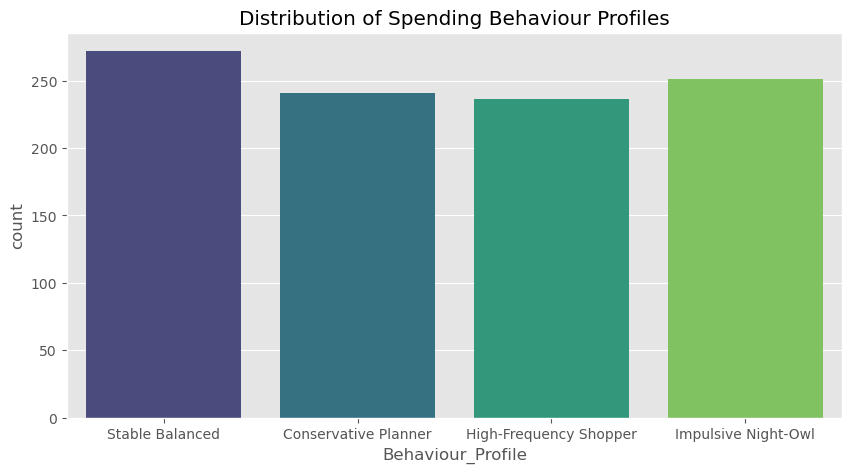

In [43]:
# Visualization 1: Profile Distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=user_metrics,
              x='Behaviour_Profile',
              palette='viridis')
plt.title('Distribution of Spending Behaviour Profiles')
plt.show()

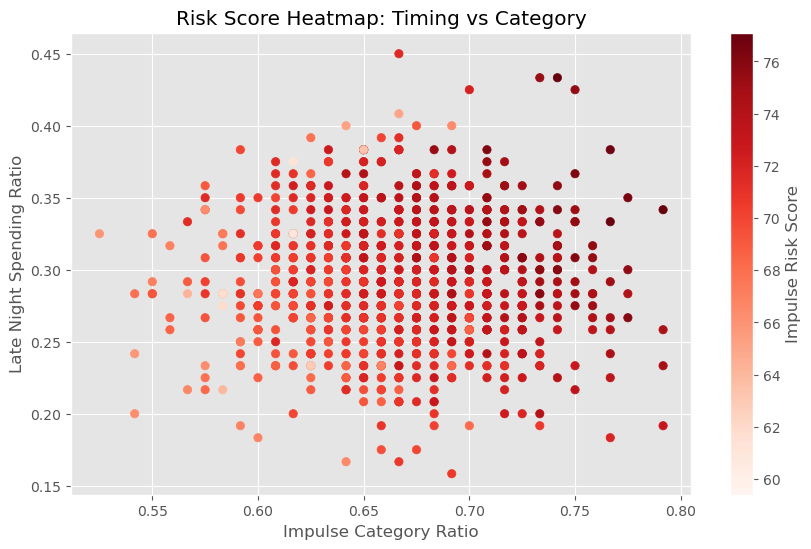


Processing Complete.
Files 'final_user_behaviour_analysis.csv' and 'enriched_transactions_data.csv' are ready.


In [44]:
# Visualization 2: Risk Score Heatmap

plt.figure(figsize=(10, 6))
plt.scatter(user_metrics['Impulse_Ratio'],
            user_metrics['Late_Night_Ratio'],
            c=user_metrics['Impulse_Risk_Score'],
            cmap='Reds')

plt.colorbar(label='Impulse Risk Score')
plt.xlabel('Impulse Category Ratio')
plt.ylabel('Late Night Spending Ratio')
plt.title('Risk Score Heatmap: Timing vs Category')
plt.show()


print("\nProcessing Complete.")
print("Files 'final_user_behaviour_analysis.csv' and 'enriched_transactions_data.csv' are ready.")

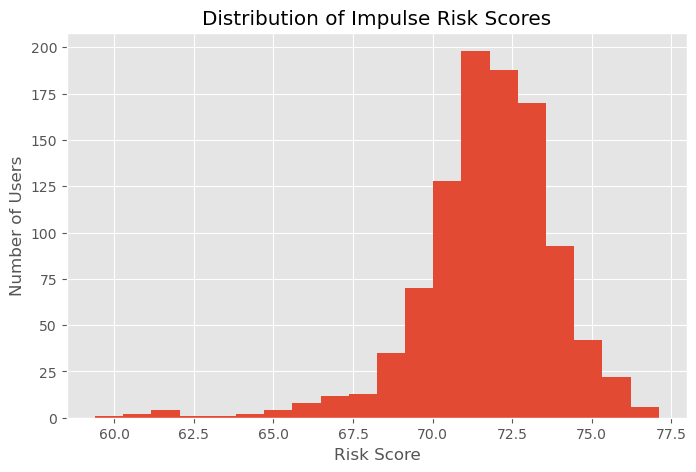

In [46]:
# Risk Score Distribution (Histogram)

plt.figure(figsize=(8,5))
plt.hist(user_metrics['Impulse_Risk_Score'], bins=20)
plt.title("Distribution of Impulse Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Users")
plt.show()

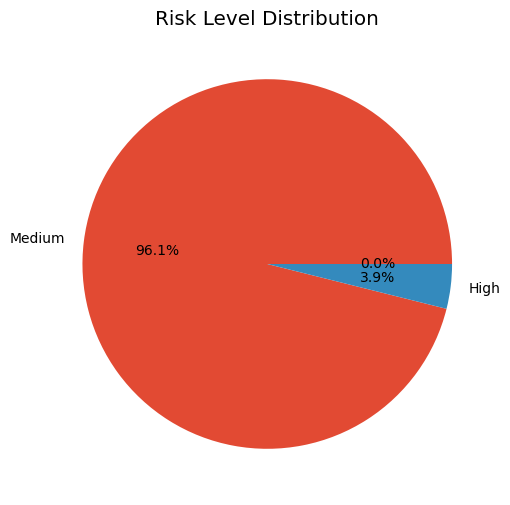

In [48]:
# Risk Category Pie Chart

plt.figure(figsize=(6,6))
user_metrics['Risk_Level'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Risk Level Distribution")
plt.ylabel("")
plt.show()

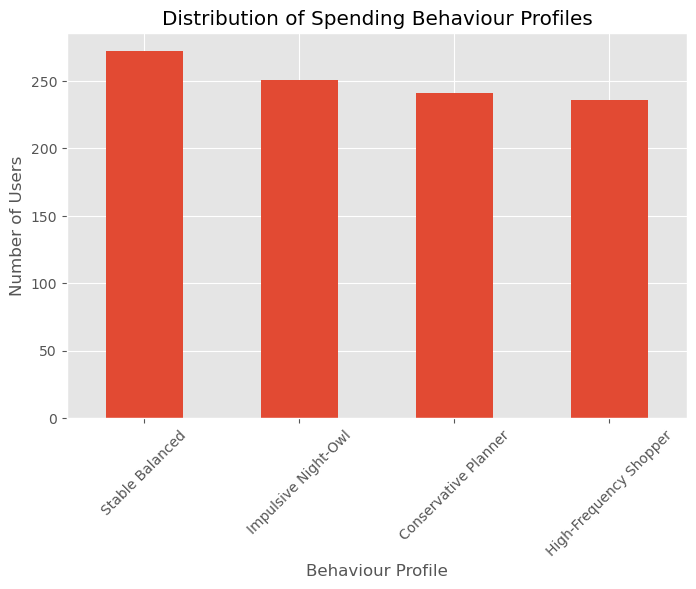

In [49]:
# Behaviour Profile Distribution

plt.figure(figsize=(8,5))
user_metrics['Behaviour_Profile'].value_counts().plot(kind='bar')
plt.title("Distribution of Spending Behaviour Profiles")
plt.xlabel("Behaviour Profile")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

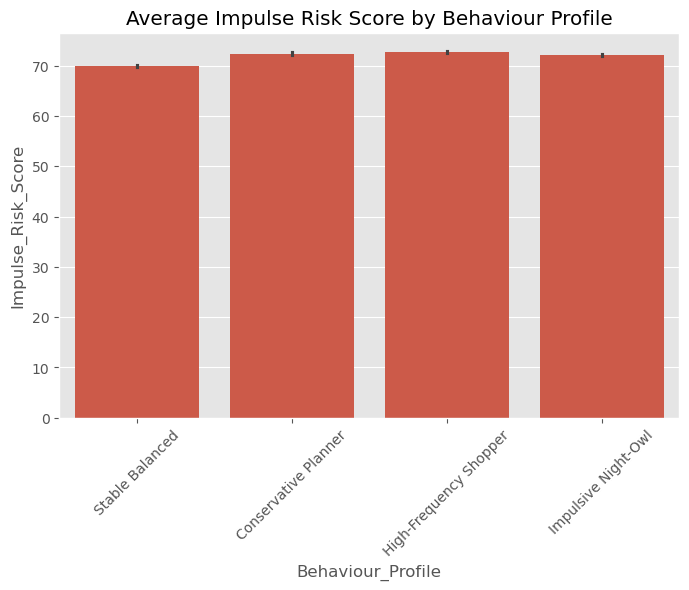

In [50]:
# Average Risk Score by Behaviour Profile

plt.figure(figsize=(8,5))
sns.barplot(x='Behaviour_Profile',
            y='Impulse_Risk_Score',
            data=user_metrics)
plt.title("Average Impulse Risk Score by Behaviour Profile")
plt.xticks(rotation=45)
plt.show()

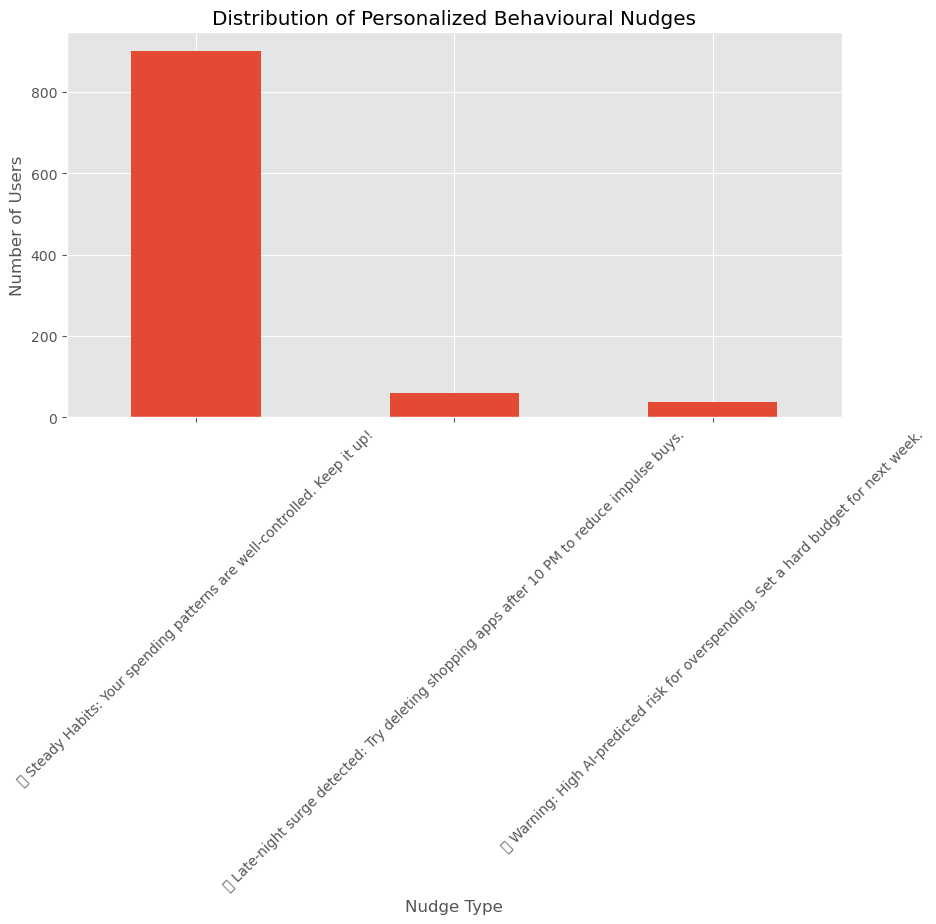

In [51]:
# Personalized Behavioural Nudges

# Nudge Distribution

plt.figure(figsize=(10,5))
user_metrics['Personalized_Nudge'].value_counts().plot(kind='bar')
plt.title("Distribution of Personalized Behavioural Nudges")
plt.xlabel("Nudge Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

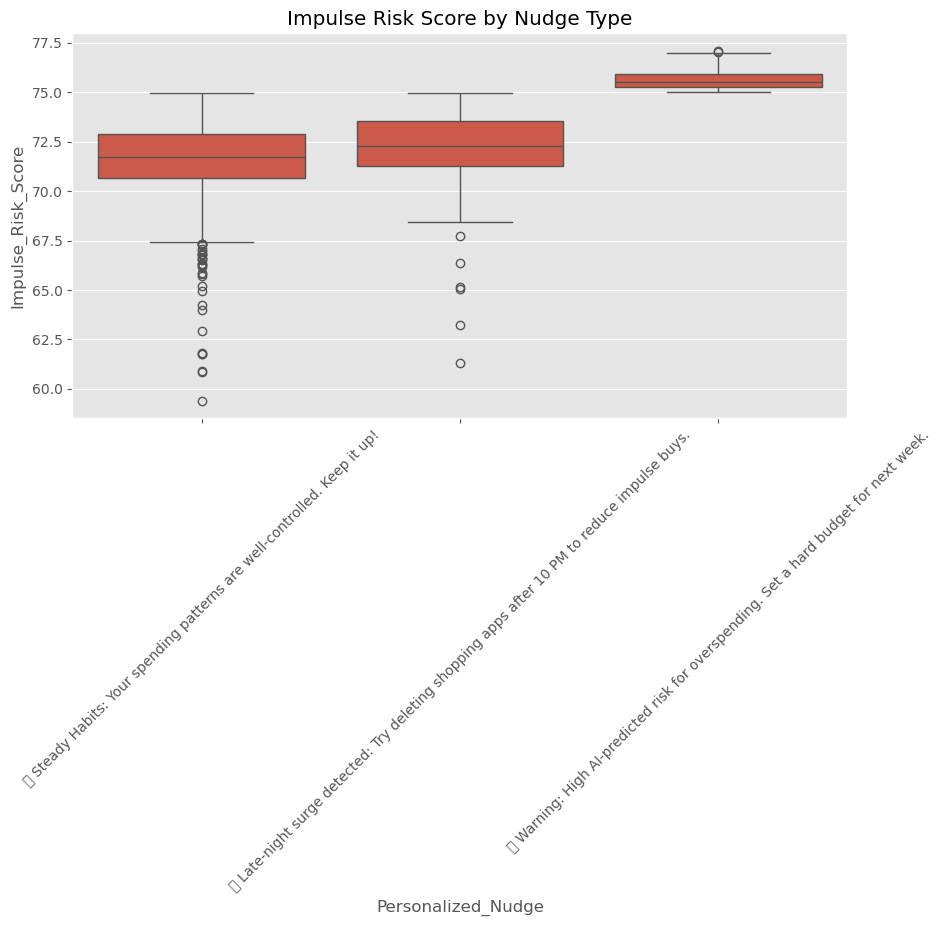

In [52]:
# Risk Score by Nudge Type

plt.figure(figsize=(10,5))
sns.boxplot(x='Personalized_Nudge',
            y='Impulse_Risk_Score',
            data=user_metrics)
plt.title("Impulse Risk Score by Nudge Type")
plt.xticks(rotation=45)
plt.show()